# Technische Universität Braunschweig - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Technische Universität Braunschweig' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/010nsgg66' -- 'Technische Universität Braunschweig'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Technische Universität Braunschweig,"Technische Universit&#x00E4;t Braunschweig,Bra...",https://openalex.org/W4360764827
1,not assigned,Technische Universität Braunschweig,Nagarajan Ganapathy is research Associate at P...,https://openalex.org/W4295422297
2,not assigned,Technische Universität Braunschweig,Nagarajan Ganapathy is research Associate at P...,https://openalex.org/W4295422297
3,not assigned,Technische Universität Braunschweig,"Technische Universit&#x00E4;t Braunschweig,Inf...",https://openalex.org/W4290996454
4,not assigned,Technische Universität Braunschweig,Peter L. Reichertz Institute for Medical Infor...,https://openalex.org/W4310933286


In [1128]:
MAPPING_DICT = {
    'Zentrum für Pharmaverfahrenstechnik': ['cent(er|re) (of|for) pharmaceutical eng(i|e)neering'], #selbst ergänzt
    'Cluster of Excellence SE2A': ['se(2|²)a', 'efficient aviation'], #selbst ergänzt
    'Braunschweig Integrated Centre of Systems Biology (BRICS)': ['(brics)', 'systems biology'],
    'Carl-Friedrich-Gauß-Fakultät': ['reichertz', 'algebra', 'equations', 'differentialgleichungen', '(automotive|information) management', 'numeri(sche|cal) mathe',
                                     'public policy', 'scientific computing', 'soziologie', 'operating systems', 'computer science', 'wirtschaftsinformatik',
                                     'medical informatics', 'mathematical optimization', 'graphi(k|cs)', 'roboti(k|cs)', 'stochasti(k|cs)', 'application security',
                                     'industrial production', 'numerical', 'finance', 'economics', 'enterprise', '(department|institute) of mathematics', 'communication science',
                                     'international(e)? (relations|beziehungen)', 'sociology', 'dienstleistungsmanagement', 'information systems', 'software engineering',
                                     'unternehmensführung', 'chip design', 'computational (science|mathematics)', 'volkswirtschaftslehre', 'marketing',
                                     'management control', 'reactive systems', 'business science'
                                    ],
    'Carolo-Wilhelmina-Forschungszentren': ['metrolog(ie|y)', 'carolo-wilhelmina'],
    'Fakultät Architektur, Bauingenieurwesen und Umweltwissenschaften': ['geod(äsie|esy)', 'geo(chemie|technik|ecology)', 'wood(-|‐)based (construction|materials)', 
                                                                         'construction (design|management)', 'leich(t)?wei(ß|ss)?',
                                                                         '(steel|timber) structures', 'civil engineering', 'geosystems', '(solid|concrete) construction',
                                                                         'water resources', '(wasser|holz|massiv|stahl)bau', 'landscape ecology', 'architecture',
                                                                         'tragwerksentwurf', 'applied mechanics', 'urban(?!e\swissen)', 'design research',
                                                                         'statik', 'materials science', 'geosysteme', 'hydrology', 'geoökologie',
                                                                         'hydraulic engineering', 'structural (analysis|design)', 'sanitary', 'railway', 
                                                                         'bau(wirtschaft|werkserhaltung)', 'waste', 'pavement', 'fire safety'
                                                                        ],
    'Fakultät für Elektrotechnik, Informationstechnik, Physik': ['(theoretische|mathematische|angewandte) physik', 'geophysi(k|cs)', 'electromagnetic', 'high voltage',
                                                                 'semiconductor', '(ifn)', 'electrical machines', '(control|network|electrical) engineering',
                                                                 'communication(s)? (technology|network)', 'halbleitertechnik', 'kondensierten materie',
                                                                 'cmos(,| design)', '(applied|theoretical|mathematical|matter) physic(s)?', 'datentechnik',
                                                                 'hochfrequenztechnik', 'elektrotechnik', 'hochspannungstechnik', 'high(-|\s)frequency(\smeas.)? techn(ik|ology)',
                                                                 'nachrichtentechnik', 'photonic', 'emc,', 'information theory' 
                                                                ],
    'Fakultät für Geistes- und Erziehungswissenschaften': ['sport(s)? science', 'fachdidaktik', '(german|american) studies', 'geschichtswissenschaft', 'education',
                                                           'philosophy', 'erziehungswissenschaft', 'bewegungspädagogik', 'germanistik', 'pädagogische',
                                                           'historisches seminar', 'english linguistics', 'sprachwissenschaft', 'theolog(ie|y)'
                                                          ],
    'Fakultät für Lebenswissenschaften': ['pharma(?!verfahrenstechnik)', 'neurobiology', 'psychotherap(ie|y)', 'zoolog(y|ical)', 'plant biology', 
                                          '(theoretische|organische|analytische|technische) chemie', '(physical|analytical|theoretical|technical|organic|sustainable) chemistry', 
                                          '(institut(e)?|department) (of|f(ü)?r|for|fuer) psycholog(ie|y)',
                                          'food chemistry', 'bioinformatics', 'mi(k|c)robiolog(ie|y)', 'lebensmittelchemie', 'biotechnolog(ie|y)', 'geneti(k|cs)',
                                          'electrocatalysis', 'social psychology', 'zoologische(s)?', 'klinische psychologie', 'life sciences', 'sociotechnical',
                                          '(engineering|traffic) psychology', '(sozial|verkehrs)psychologie', 'pflanzenbiologie', 'physiology', 'biochemistry'
                                         ],
    'Fakultät für Maschinenbau': ['thermal (process|engineering)', 'turbomachinery', 'dynamics and vibrations', 'werkzeugmaschinen', 'joining', 'machine tools',
                                  'fluid(s)? (mechanics|dynamics)', 'aerospace', 'a(k|co)ust(.|i(k|cs))', 'aviation', 'particle(s)? technology', 'institut für werkstoffe',
                                  'biochemical engineering', 'process systems engineering', 'engineering design', '(mechanical|automotive) engineering', 'adaptroni(k|cs)',
                                  'logistic(s)? systems', 'aircraft', '(schweiß|partikel)technik', 'mi(k|c)ro(\s)?tech(n)?(ik|ology)', 
                                  'flight guidance', 'flugf(ü|u)hrung', 'mobile maschinen', 'combustion', 'raumfahrtsysteme',
                                  'space systems', 'maschinenbau', '(surface|automotive) technology', 'str(o|ö)mungs(maschinen|mechanik)', 'thermodynami(k|cs)',
                                  '(produktionsmess|konstruktions)techni(c)?k', 'vehicle drives', 'production measurement', 'flugzeugbau', 'thermische verfahrenstechnik',
                                  'dynamik und schwingungen', 'verbrennungskraftmaschinen', '(iprom)', 'intermodal'
                                 ],
    'Niedersächsisches Forschungszentrum Fahrzeugtechnik (NFF)': ['center for automotive'],
    #'Niedersächsisches Forschungszentrum für Luftfahrt (NFL)': [],
    'Universitätsbibliothek': ['universitätsbibliothek'],
    #'Zentrale Einrichtung Botanischer Garten': [],
    'Battery Labfactory Braunschweig': ['battery lab(\s)?factory'], # selbst ergänzt
    'Forschungszentrum Küste (FZK)': ['coastal research cent(er|re)', 'forschungszentrum k(ü|u)ste'], #selbst ergänzt
    'Forschungszentrum L3S': ['l3s'], #selbst ergänzt
}

In [1129]:
with open('./mapping_tables_fak/tubraunschweig.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [1130]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [1131]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [1132]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Technische Universität Braunschweig,"Technische Universit&#x00E4;t Braunschweig,Bra...",https://openalex.org/W4360764827
1,Carl-Friedrich-Gauß-Fakultät,Technische Universität Braunschweig,Nagarajan Ganapathy is research Associate at P...,https://openalex.org/W4295422297
2,Carl-Friedrich-Gauß-Fakultät,Technische Universität Braunschweig,Nagarajan Ganapathy is research Associate at P...,https://openalex.org/W4295422297
3,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,"Technische Universit&#x00E4;t Braunschweig,Inf...",https://openalex.org/W4290996454
4,Carl-Friedrich-Gauß-Fakultät,Technische Universität Braunschweig,Peter L. Reichertz Institute for Medical Infor...,https://openalex.org/W4310933286
...,...,...,...,...
15056,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Braunschw...",https://openalex.org/W4312580423
15057,Fakultät für Maschinenbau,Technische Universität Braunschweig,"TU Braunschweig, Institute of Aircraft Design ...",https://openalex.org/W4224997450
15058,"Fakultät Architektur, Bauingenieurwesen und Um...",Technische Universität Braunschweig,Department of Organic and Wood-Based Construct...,https://openalex.org/W4311837786
15059,Carl-Friedrich-Gauß-Fakultät,Technische Universität Braunschweig,"Technical University of Braunschweig, Institut...",https://openalex.org/W4301368852


In [1133]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[40:60]

array(['TU Braunschweig and CESifo, Germany',
       'Technical University Braunschweig, Braunschwieg, Germany',
       'TU Braunschweig,Braunschweig,Germany',
       'Junior Research Group, Communicating Scientists: Challenges, Competencies, Contexts (fourC), Technische Universität Braunschweig, Braunschweig, Germany',
       'Universität Braunschweig, Mühlenpfordtstraße 23, 38106, Braunschweig, Deutschland',
       'Technische Universität Braunschweig, 38106 Braunschweig, Germany',
       'Braunschweig University, Germany',
       'Technische Universität Braunschweig, Braunschweig, 38108, Germany',
       'Technische Universität Braunschweig (iBMB), Braunschweig, Germany',
       'Technische Universit&#x00A8;at,Braunschweig,Germany',
       'Technische Universität Braunschweig = Technical University of Braunschweig [Braunschweig]',
       'Department of Mathematical Modelling and Data Analysis, Physikalisch-Technische Bundesanstalt Braunschweig und Berlin, Abbestrasse 2-12, D-10587 B

In [1134]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Battery Labfactory Braunschweig,173
1,Braunschweig Integrated Centre of Systems Biol...,518
2,Carl-Friedrich-Gauß-Fakultät,1213
3,Carolo-Wilhelmina-Forschungszentren,549
4,Cluster of Excellence SE2A,124
5,"Fakultät Architektur, Bauingenieurwesen und Um...",1449
6,"Fakultät für Elektrotechnik, Informationstechn...",1911
7,Fakultät für Geistes- und Erziehungswissenscha...,183
8,Fakultät für Lebenswissenschaften,3333
9,Fakultät für Maschinenbau,2740


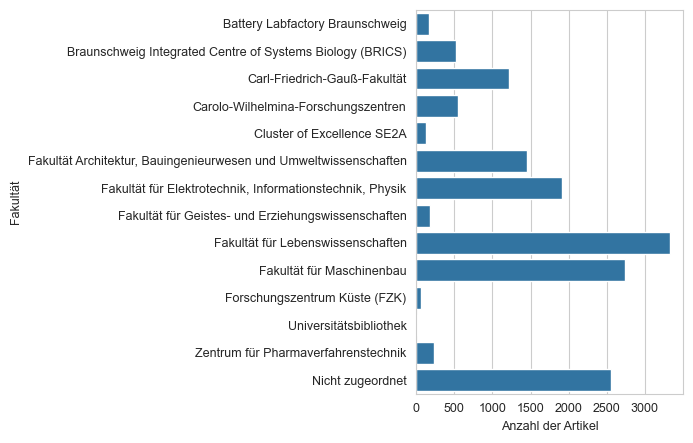

In [1135]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [1136]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8304893433370958

In [1137]:
MAPPING_DICT_DEPT = {
    'Carl-Friedrich-Gauß-Fakultät': {
        'Department für Sozialwissenschaften': ['sozialwissenschaften', 'comparative politics', 'so(z|c)iolog(ie|y)', 'communication science', 'international relations',
                                                'internationale beziehungen'
                                               ],
        'Department Informatik': ['computer(\s)?(science|graphi(k|c)|network)', 'reichertz', 'roboti(k|cs)', 'medical informatics', 'software engineering',
                                  'information systems', '(embedded|scientific) computing', 'application security'
                                 ],
        'Department Mathematik': ['analysis', 'differential', 'mathemati', 'stochastik'],
        'Department Wirtschaftswissenschaften': ['wirtschaftsinformatik', '(information|automotive) management', 'unternehmensführung', 'economics', 'finance',
                                                 'enterprise', 'dienstleistungsmanagement', 'industrial production', 'marketing'
                                                ],
    },
    'Fakultät Architektur, Bauingenieurwesen und Umweltwissenschaften': {
        #'Bet Tfila - Forschungsstelle für jüdische Architektur in Europa': [],
        'Department Architektur': ['design', 'tragwerksentwurf', '(?<!faculty of\s)archite(k|c)tur', 'urbanism'],
        'Department Bauingenieurwesen und Umweltwissenschaften': ['geo(ecology|system|technik|chemie)', 'leich(t)?wei(ß|ss)?', 'building materials', 'steel', 'applied mechanics',
                                                                  'material(s)? (science|building)', 'photogrammetr(ie|y)', 'computational model(l)?ing', 'structural analysis',
                                                                  'timber', 'wood(-|‐)based', 'landscape ecology', '(massiv|holz|stahl)bau', 'statik und dynamik',
                                                                  'bauwirtschaft', 'geoökologie', 'sanitary', 'construction management', 'railway', 'statik',
                                                                  'bauwerkserhaltung', 'hydrolog(ie|y)', 'coastlines', 'hydraulic', 'concrete construction', 'waste',
                                                                  'urban engineering'
                                                                 ],
        'Institut für Planung des öffentlichen Verkehrs': ['urban engineering', 'pavement'],
        #'Juniorprofessur Gender.ING': [],
    },
    'Fakultät für Elektrotechnik, Informationstechnik, Physik': {
        'Abteilung für Physik': ['geophysi(k|cs)', 'angewandt', 'applied', 'mathemati(sch|c)', 'kondensiert', 'condensed', 'theoreti(sch|cal)'],
        'Institut für CMOS Design': ['cmos'],
        'Institut für Datentechnik und Kommunikationsnetze': ['kommunikationsnetze', 'network engineering', 'communication(s)? network'],
        'Institut für Elektrische Maschinen, Antriebe und Bahnen': ['elektrische maschinen', 'electrical machines'],
        'Institut für Elektrische Messtechnik und Grundlagen der Elektrotechnik': ['grundlagen der elektrotechnik', 'electrical measurement'],
        'Institut für Elektromagnetische Verträglichkeit': ['ele(k|c)tromagneti(sch|c)', 'emc,'],
        'Institut für Halbleitertechnik': ['semiconductor', 'halbleiter'],
        'Institut für Hochfrequenztechnik': ['hochfrequenztechnik', 'photonic', 'high(-|\s)frequency'],
        'Institut für Hochspannungstechnik und Energiesysteme - elenia': ['hochspannungstechnik', 'elenia', 'high voltage'],
        'Institut für Nachrichtentechnik': ['nachrichtentechnik', 'commun(.|ication(s)?) technol(.|ogy)', 'information theory'],
        'Institut für Regelungstechnik': ['regelungstechnik', 'control engineering'],
    },
    'Fakultät für Geistes- und Erziehungswissenschaften': {
        'Institut für Anglistik und Amerikanistik': ['english linguistic', 'american studies', 'sprachwissenschaft'],
        'Institut für Didaktik der Mathematik und Elementarmathematik': ['mathemati(k|cs)'],
        'Institut für Erziehungswissenschaften': ['institut für erziehung', 'general didactics', 'institute for educational science'],
        'Institut für Fachdidaktik der Naturwissenschaften': ['naturwissenschaften', 'natural science', 'biology'],
        'Institut für Germanistik': ['germanistik', 'german studies'],
        'Institut für Geschichtswissenschaft': ['geschicht(e|swissenschaft)'],
        'Institut für Musik und ihre Vermittlung': ['musik'],
        'Institut für Pädagogische Psychologie': ['psycholog(ie|y)'],
        'Institut für Sportwissenschaft und Sportpädagogik': ['sport(s)? science', 'sportwissenschaft', 'bewegungspädagogik'],
        'Seminar für Evangelische Theologie und Religionspädagogik': ['evangelisch', 'theolog(ie|y)'],
        'Seminar für Philosophie': ['philosoph(ie|y)'],
    },
    'Fakultät für Lebenswissenschaften': {
        'Pharmazie': ['pharma(zie|cy|ceutical|cology|zeutische|kologie)'],
        'Biologie/Biotechnologie': ['bio(log(ie|y)|technolog(ie|y))', 'geneti(k|cs)', 'zoologi(sch|cal)', 'cell physiology', 'biochemistry'],
        'Chemie/Lebensmittelchemie': ['chemi(e|stry)', 'electrocatalysis'],
        'Psychologie': ['psycho(log(ie|y)|therap(ie|y))'],
        #'Zentrale Einrichtung Massenspektrometrie': [],
        #'Zentrale Einrichtung Röntgenstrukturanalyse': [],
        #'Zentrales NMR-Labor der Chemischen Institute': [],
    },
    'Fakultät für Maschinenbau': {
        'Institut für Mechanik und Adaptronik': ['adaptroni(k|cs)'],
        'Forschungsbereich Energie- und Verfahrenstechnik': ['process systems', 'partikeltechnik', 'particle(s)? technology', 'thermal (process|engineering)', 
                                                             'thermodynami(k|c)', 'biochemical', 'thermische'
                                                            ],
        'Forschungsbereich Kraftfahrzeugtechnik': ['engineering design', 'konstruktionstechnik', 'automotive', 'combustion', 'verbrennungskraftmaschinen',
                                                   'vehicle drives', 'mobile ma(s)?chine(n|s)'
                                                  ],
        'Forschungsbereich Luft- und Raumfahrttechnik': ['fluid (mechanics|dynamics)', 'flight guidance', 'werkstoffe', 'turbomachinery', 'space systems', 'aircraft', 
                                                         'aviation', 'flug(f(ü|u)hrung|zeugbau|antriebe)', 'aerospace', 'str(ö|o)mungsmechanik'
                                                        ],
        'Forschungsbereich Produktions- und Systemtechnik': ['(prod(uc|cu)tion|manufacturing) (technolog(y|ies)|engineering|measurement)', 'joining and welding', 
                                                             'mi(k|c)ro(\s)?tech(n)?(ik|olog(ie|y))', 'produktionsmesstechni(c)?k',
                                                             'surface technology', 'werkzeugmaschinen', 'schweißtechnik', '(iprom)', 'machine tools and process'
                                                            ],
        'Institut für Akustik und Dynamik': ['vibrations', 'schwingungen', 'acoust', 'akustik'],
        'Institut für Intermodale Transport- und Logistiksysteme': ['inter(-|\s)?modal(e)? transport'],
    }
}

In [1138]:
with open('./mapping_tables_dept/tubraunschweig.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [1139]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [1140]:
current_faculty = 'Fakultät für Elektrotechnik, Informationstechnik, Physik'

In [1141]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty=current_faculty)

In [1142]:
df_with_inst[(df_with_inst['fak_name'] == current_faculty) & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Faculty of Electrical Engineering, Information Technology, Physics, Technische Universität Braunschweig, Germany',
       'Fakult&#x00E4;t f&#x00FC;r Elektrotechnik, Informationstechnik, Physik, Technische Universit&#x00E4;t Braunschweig, Braunschweig, Germany',
       'Faculty of Electrical Engineering, Information Technology, Physics, Technische Universität Braunschweig, Hans-Sommer-Straße 66, Braunschweig, 38106, Germany',
       'Physics Technische Universit&#x00E4;t Braunschweig,Faculty of Electrical Engineering, Information Technology,Braunschweig,Germany',
       'Technische Universitat Braunschweig Fakultat fur Elektrotechnik Informationstechnik Physik',
       'Faculty of Electrical Engineering, Information Technology, and Physics, Technische Universität Braunschweig, Braunschweig, Germany',
       'Department of Electrical Engineering, Information Technology, Physics, Technische Universit&#x00E4;t Braunschweig, Braunschweig, Germany',
       'Department of Electrical 

In [1143]:
df_with_inst[df_with_inst['fak_name'] == current_faculty].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Abteilung für Physik,599
1,Institut für CMOS Design,112
2,Institut für Datentechnik und Kommunikationsnetze,89
3,"Institut für Elektrische Maschinen, Antriebe u...",68
4,Institut für Elektrische Messtechnik und Grund...,45
5,Institut für Elektromagnetische Verträglichkeit,71
6,Institut für Halbleitertechnik,223
7,Institut für Hochfrequenztechnik,155
8,Institut für Hochspannungstechnik und Energies...,142
9,Institut für Nachrichtentechnik,359


In [1144]:
df_with_inst[df_with_inst['fak_name'] == current_faculty]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
3,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,"Technische Universit&#x00E4;t Braunschweig,Inf...",https://openalex.org/W4290996454,Institut für Nachrichtentechnik
6,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,Institut fÃ¼r Geophysik und extraterrestrische...,https://openalex.org/W4224286617,Abteilung für Physik
19,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,"Institut für Physik der Kondensierten Materie,...",https://openalex.org/W4312057260,Abteilung für Physik
26,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,Department High Frequency and Electromagnetic ...,https://openalex.org/W4320150671,Institut für Elektromagnetische Verträglichkeit
27,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,"Hz-Photonics Group, Technische Universität Bra...",https://openalex.org/W4320150671,Institut für Hochfrequenztechnik
...,...,...,...,...,...
15043,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,Institute of Semiconductor Technology Technisc...,https://openalex.org/W4311415683,Institut für Halbleitertechnik
15044,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,Institute of Semiconductor Technology Technisc...,https://openalex.org/W4311415683,Institut für Halbleitertechnik
15045,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,Institute of Semiconductor Technology Technisc...,https://openalex.org/W4311415683,Institut für Halbleitertechnik
15046,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,Institute of Semiconductor Technology Technisc...,https://openalex.org/W4311415683,Institut für Halbleitertechnik


In [1145]:
MAPPING_DICT_INST = {
    'Department für Sozialwissenschaften': {
        'Institut für Internationale Beziehungen': ['international relations', 'internationale beziehungen'],
        'Institut für Kommunikationswissenschaft': ['communication science'],
        'Institut für Soziologie - Abteilung Arbeit und Organisation': ['arbeit und organisation'],
        #'Institut für Soziologie - Abteilung Sozialstrukturanalyse & empirische Sozialforschung': [],
        'Institut für Vergleichende Regierungslehre und Politikfeldanalyse (CoPPP)': ['coppp', 'public policy'],
    },
    'Department Informatik': {
        'Institut für Anwendungssicherheit': ['application security'],
        'Institut für Betriebssysteme und Rechnerverbund': ['operating systems', 'chip design', 'algorithm'],
        'Institut für Computergraphik': ['computer(\s)?graphi(k|c)'],
        'Institut für Informationssysteme': ['information systems'],
        'Institut für Robotik und Prozessinformatik': ['roboti(k|cs)'],
        'Institut für Softwaretechnik und Fahrzeuginformatik': ['software engineering'],
        'Institut für Systemsicherheit': ['systemsicherheit'],
        'Institut für Theoretische Informatik': ['theoreti(sch|cal)'],
        'Institut für Wissenschaftliches Rechnen': ['scientific computing'],
        'Peter L. Reichertz Institut für Medizinische Informatik': ['medical informa(c)?tics', 'medizinische informatik', 'reichertz'],
    },
    'Department Mathematik': {
        'Institut für Analysis und Algebra': ['algebra', 'analysis'],
        'Institut für Mathematische Optimierung': ['mathematical optimization'],
        'Institut für Mathematische Stochastik': ['math(.|ematische) stochastik', 'mathematical stochastics'],
        'Institut für Numerische Mathematik': ['(numerical|computational) mathematics', 'numerische mathematik'],
        'Institut für Partielle Differentialgleichungen': ['parti(el|al)'],
        #'Institut für Statistik und Grundlagen des Maschinellen Lernens': [],
    },
    'Department Wirtschaftswissenschaften': {
        'Institut für Automobilwirtschaft und Industrielle Produktion': ['dienstleistungsmanagement', 'automotive (management|industry|research)'],
        #'Institut für Controlling und Unternehmensrechnung': [],
        'Institut für Finanzwirtschaft': ['finance'],
        'Institut für Marketing': ['marketing'],
        #'Institut für Rechtswissenschaften': [],
        'Institut für Unternehmensführung': ['unternehmensführung'],
        #'Institut für Volkswirtschaftslehre': [],
        'Institut für Wirtschaftsinformatik': ['information(\s)?management', 'wirtschaftsinformatik', 'data(-|‐)driven'],
    },
    'Department Architektur': {
        #'Institut für Architekturbezogene Kunst': [],
        'Institut für Baugeschichte': ['baugeschichte'],
        'Institut für Bauklimatik und Energie der Architektur': ['climatology'],
        'Institut für Baukonstruktion': ['baukonstruktion'],
        #'Institut für Entwerfen und Baugestaltung': [],
        #'Institut für Entwerfen und Gebäudelehre': [],
        'Institut für Entwerfen und Raumkompositionen': ['raumkompositionen'],
        #'Institut für Experimentelles Entwerfen': [],
        'Institut für Geschichte und Theorie der Architektur und Stadt': ['theor(ie|y)'],
        #'Institut für Gestaltungsmethodik und Darstellung (IMDR)': [],
        'Institut für Konstruktives Entwerfen, Industrie- und Gesundheitsbau': ['constructi(on|ve) design'],
        'Institut für Landschaftsarchitektur': ['landschaftsarchitektur'],
        #'Institut für Städtebau und Entwurfsmethodik': [],
        'Institut für Tragwerksentwurf': ['tragwerksentwurf', 'structural design'],
        'Institute for Sustainable Urbanism': ['sustainable urbanism'],
    },
    'Department Bauingenieurwesen und Umweltwissenschaften': {
        'Institut für Angewandte Mechanik': ['applied mechanics'],
        'Institut für Baukonstruktion und Holzbau': ['(wood(-|‐)|timber\s)(based|structures)', 'holzbau'],
        'Institut für Baustoffe, Massivbau und Brandschutz': ['building materials', 'materials science', 'baustoffe', 'massivbau', 'concrete construction'],
        'Institut für Bauwirtschaft und Baubetrieb': ['bauwirtschaft', 'construction management'],
        'Institut für Eisenbahnwesen und Verkehrssicherung': ['traffic safety'],
        'Institut für Geodäsie und Photogrammetrie': ['geodesy', 'geodäsie'],
        'Institut für Geomechanik und Geotechnik': ['geomechanik'],
        'Institut für Geosysteme und Bioindikation': ['geosystem'],
        'Institut für Geoökologie': ['geoecology', 'geoökologie', 'umweltgeochemie', 'landscape ecology'],
        'Institut für Rechnergestützte Modellierung im Bauingenieurwesen': ['computational model(l)?ing'],
        'Institut für Siedlungswasserwirtschaft': ['sanitary'],
        'Institut für Stahlbau': ['stahlbau', 'steel structures', 'bauwerkserhaltung'],
        'Institut für Statik und Dynamik': ['structural analysis', 'dynamik', 'institut f(ü)?r statik'],
        'Institut für Straßenwesen': ['straßenwesen'],
        'Institut für Verkehr und Stadtbauwesen': ['urban engineering'],
        'Institut für Verkehrswesen, Eisenbahnbau und -betrieb': ['railway construction'],
        'Leichtweiß-Institut für Wasserbau': ['leich(t)?wei(ß|ss)?', 'resource management', 'hydraulic', 'hydrology', 'coastlines'],
        #'Studiengang Computational Sciences in Engineering': [],
    },
    'Abteilung für Physik': {
        'Institut für Angewandte Physik': ['angewandt', 'applied'],
        'Institut für Geophysik und Extraterrestrische Physik': ['geophysi(k|cs)'],
        'Institut für Mathematische Physik': ['mathemati(sch|c)'],
        'Institut für Physik der Kondensierten Materie': ['kondensiert', 'condensed'],
        'Institut für Theoretische Physik': ['theoreti(sch|cal)'],
    },
    'Institut für Anglistik und Amerikanistik': {
        'Abteilung Englische Sprache und ihre Didaktik': ['didaktik'],
        'Abteilung Englische Sprachwissenschaft': ['sprachwissenschaft', 'english linguistics'],
        'Abteilung Literatur- und Kulturwissenschaften': ['kulturwissenschaften'],
    },
    'Institut für Erziehungswissenschaften': {
        'Abteilung Allgemeine Pädagogik': ['allgemeine pädagogik'],
        'Abteilung Außerschulische Bildungsforschung': ['bildungsforschung'],
        'Abteilung Schulpädagogik und Allgemeine Didaktik': ['dida(k|c)ti(k|c)'],
        'Abteilung Weiterbildung und Medien': ['medien'],
    },
    'Institut für Fachdidaktik der Naturwissenschaften': {
        'Abteilung Biologie und Biologiedidaktik': ['biolog(ie|y)'],
        'Abteilung Chemie und Chemiedidaktik': ['chemi(e|stry)'],
        'Abteilung Physik und Physikdidaktik': ['physi(k|c)'],
        'Abteilung Sachunterricht und seine Didaktik': ['sachunterricht'],
    },
    'Institut für Germanistik': {
        'Abteilung Didaktik der deutschen Sprache und Literatur': ['didaktik'],
        'Abteilung Linguistik und Mediävistik': ['linguistik'],
        'Abteilung Neuere deutsche Literatur': ['neuere'],
    },
    'Institut für Geschichtswissenschaft': {
        'Abteilung Alte und Mittelalterliche Geschichte': ['mittelalter'],
        'Abteilung Geschichte und Geschichtsdidaktik': ['didaktik'],
        'Abteilung Neuere Geschichte': ['neuere'],
        'Abteilung Wissenschafts- u Technikgeschichte': ['technik'],
    },
    'Biologie/Biotechnologie': {
        'Institut für Biochemie, Biotechnologie und Bioinformatik': ['biochemi(e|stry)', 'molecular cell'],
        'Institut für Genetik': ['geneti(k|cs)'],
        'Institut für Mikrobiologie': ['mi(k|c)robiolog(ie|y)'],
        'Institut für Pflanzenbiologie': ['pflanzen', 'plant'],
        'Institut für Zell- und Neurobiologie (IZN)': ['neurobiolog(ie|y)', 'zoologi(sch|cal)', 'cell physiology'],
    },
    'Chemie/Lebensmittelchemie': {
        'Institut für Anorganische und Analytische Chemie': ['analyti(sch|cal)'],
        'Institut für Lebensmittelchemie': ['institut(e)? of food', 'institut f(ü)?r leben'],
        'Institut für Organische Chemie': ['organi(sch|c)'],
        'Institut für Physikalische und Theoretische Chemie': ['physi(k|c)ali(sch|c)', 'theoretical'],
        'Institut für Technische Chemie': ['techni(sch|cal)'],
        'Institut für Ökologische und Nachhaltige Chemie': ['ökologisch', 'sustainable'],
    },
    'Pharmazie': {
        'Abteilung für Geschichte der Naturwissenschaften mit Schwerpunkt Pharmaziegeschichte': ['geschichte', 'history'],
        'Institut für Medizinische und Pharmazeutische Chemie': ['chemi(e|stry)'],
        'Institut für Pharmakologie, Toxikologie und Klinische Pharmazie': ['toxi(k|c)olog(ie|y)'],
        'Institut für Pharmazeutische Biologie': ['biolog(ie|y)'],
        'Institut für Pharmazeutische Technologie und Biopharmazie': ['technolog(ie|y)'],
    },
    'Psychologie': {
        'Institut für Psychologie': ['psycho']
    },
    'Forschungsbereich Energie- und Verfahrenstechnik': {
        'Institut für Bioverfahrenstechnik': ['bioverfahren', 'biochemical'],
        'Institut für Chemische und Thermische Verfahrenstechnik': ['(?<!bio)chemi(sch|cal)'],
        'Institut für Energie- und Systemverfahrenstechnik': ['system'],
        'Institut für Partikeltechnik': ['parti(kel|cle)'],
        'Institut für Thermodynamik': ['thermo'],
    },
    'Forschungsbereich Kraftfahrzeugtechnik': {
        'Institut für Fahrzeugtechnik': ['institute (of|for) automotive engineering'],
        'Institut für Konstruktionstechnik': ['konstruktionstechnik', 'engineering design'],
        'Institut für mobile Maschinen und Nutzfahrzeuge': ['(mobile|vehicle) (ma(s)?chin|drives)'],
        'Institut für Verbrennungskraftmaschinen': ['combustion', 'verbrennung'],
        'Institut für Verkehrssicherheit und Automatisierungstechnik': ['verkehrssicherheit'],
    },
    'Forschungsbereich Luft- und Raumfahrttechnik': {
        'Institut für Flugantriebe und Strömungsmaschinen (IFAS)': ['turbomachinery'],
        'Institut für Flugführung': ['guidance', 'flugf(ü|u)hrung'],
        'Institut für Flugzeugbau und Leichtbau': ['leichtbau', 'lightweight'],
        'Institut für Raumfahrtsysteme': ['space system'],
        'Institut für Strömungsmechanik': ['fluid (mechanics|dynamics)', 'str(ö|o)mungs(mechanik|maschinen)'],
        'Institut für Werkstoffe': ['werkstoffe'],
    },
    'Forschungsbereich Produktions- und Systemtechnik': {
        #'Institut für Fabrikbetriebslehre und Unternehmensforschung': [],
        'Institut für Füge- und Schweißtechnik': ['welding', 'schweiß'],
        'Institut für Mikrotechnik': ['mi(k|c)ro(\s)?tech'],
        'Institut für Oberflächentechnik': ['surface technology'],
        'Institut für Produktionsmesstechnik': ['produktionsmess', 'measurement', 'iprom'],
        'Institut für Werkzeugmaschinen und Fertigungstechnik': ['machine tools', 'fertigungstechnik'],
    }
}

In [1146]:
with open('./mapping_tables_inst/tubraunschweig.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_INST, f, ensure_ascii=False)

In [1147]:
def map_inst(address: str, department: str) -> Union[str, None]:
    if department in MAPPING_DICT_INST:
        for k, v in MAPPING_DICT_INST.get(department).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [1148]:
current_faculty = 'Fakultät für Geistes- und Erziehungswissenschaften'
current_department = 'Institut für Germanistik'

In [1149]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

df_with_inst.loc[df_with_inst['dept_name'] == current_department, 'inst_name'] = \
    df_with_inst.loc[df_with_inst['dept_name'] == current_department]['raw_affiliation_string'].apply(map_inst, 
                                                                                                      department=current_department)

In [1150]:
df_with_inst[(df_with_inst['dept_name'] == current_department) & df_with_inst['inst_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Technische Universität Braunschweig , Institut für Germanistik , Bienroder Weg 80 , Braunschweig Germany',
       'TU Braunschweig , Institut für Germanistik , Bienroder Weg 80 , D- Braunschweig Germany',
       'TU Braunschweig , Institut für Germanistik , Bienroder Weg 80 , Braunschweig Germany',
       'Technische Universität Braunschweig , Institut für Germanistik , Bienroder Weg 80, D-38106 Braunschweig Germany',
       'Department of German Studies, Technische Universität Braunschweig, Braunschweig, Germany',
       'TU Braunschweig , Institut für Germanistik , Bienroder Weg 80, D-38106 Braunschweig Germany',
       'Institut für Germanistik Technische Universität Braunschweig Bienroder Weg 80 D-38106 Braunschweig Braunschweig Deutschland',
       'Department of German Studies, Technical University of Braunschweig, Braunschweig, Germany',
       'TU Braunschweig, Institut für Germanistik Braunschweig Deutschland'],
      dtype=object)

In [1151]:
df_with_inst[df_with_inst['dept_name'] == current_department].groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Abteilung Didaktik der deutschen Sprache und L...,1
1,Abteilung Linguistik und Mediävistik,3
2,NaN,15


In [1152]:
df_with_inst[df_with_inst['dept_name'] == current_department]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name,inst_name
109,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"Technische Universität Braunschweig , Institut...",https://openalex.org/W4290771387,Institut für Germanistik,None
1138,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"TU Braunschweig , Institut für Germanistik , B...",https://openalex.org/W4311164706,Institut für Germanistik,None
1844,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"TU Braunschweig , Institut für Germanistik , B...",https://openalex.org/W4311164288,Institut für Germanistik,None
2957,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"Technische Universität Braunschweig , Institut...",https://openalex.org/W4401464289,Institut für Germanistik,None
3728,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"Department of German Studies, Technische Unive...",https://openalex.org/W4286462373,Institut für Germanistik,None
4583,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"PD Dr., Wissenschaftliche Mitarbeiterin und Pr...",https://openalex.org/W7116310950,Institut für Germanistik,Abteilung Linguistik und Mediävistik
5787,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"Technische Universität Braunschweig , Institut...",https://openalex.org/W4412958662,Institut für Germanistik,None
6519,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"TU Braunschweig , Institut für Germanistik , B...",https://openalex.org/W4416784425,Institut für Germanistik,None
7543,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,"TU Braunschweig , Institut für Germanistik , B...",https://openalex.org/W4407378751,Institut für Germanistik,None
7772,Fakultät für Geistes- und Erziehungswissenscha...,Technische Universität Braunschweig,Institut für Germanistik – Didaktik der deutsc...,https://openalex.org/W4389991190,Institut für Germanistik,Abteilung Didaktik der deutschen Sprache und L...


In [1212]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Technische Universität Braunschweig'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

tubraunschweig_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    tubraunschweig_dicts[faculty] = faculty_dict

with open('../../data/mappings/tubraunschweig.json', mode='w', encoding='utf-8') as f:
    json.dump(tubraunschweig_dicts, f, ensure_ascii=False)